Using the Stage 1 to extract the Transmission Map and Atmospheric Light

In [1]:
import sys 

sys.path.append("..")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import torch.backends.cudnn as cudnn
import random
from mamba_ssm import Mamba

from thop import clever_format
from ptflops import get_model_complexity_info

import os
os.chdir("/workspace/dehazing")

In [2]:
def set_seed(seed):
    """Sets the seed for reproducibility across random, numpy, and torch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        cudnn.deterministic = True
        cudnn.benchmark = False

### Auxiliary Code

In [3]:
def get_pad_layer(pad_type):
    if(pad_type in ['refl','reflect']):
        PadLayer = nn.ReflectionPad2d
    elif(pad_type in ['repl','replicate']):
        PadLayer = nn.ReplicationPad2da
    elif(pad_type=='zero'):
        PadLayer = nn.ZeroPad2d
    else:
        print(f'Pad type [{pad_type}] not recognized')
    return PadLayer


class AntiAlias_Downsample(nn.Module):
    def __init__(self, channels, pad_type = 'reflect', filt_size = 3, 
                        stride = 2, pad_off = 0):
        super(AntiAlias_Downsample, self).__init__()
        self.filt_size = filt_size
        self.pad_off = pad_off
        self.pad_type = pad_type

        # Asymmetric padding (round up at the top and round down at the bottom)
        # Perfect when kernel size is 2 
        self.pad_sizes = [int(1. * (filt_size - 1) / 2), int(np.ceil(1. * (filt_size - 1) / 2)),
                          int(1. * (filt_size - 1) / 2), int(np.ceil(1. * (filt_size - 1) / 2))]
        self.pad_sizes = [pad_size + pad_off for pad_size in self.pad_sizes]
        self.stride = stride 
        self.off = int((self.stride - 1) / 2.)
        self.channels = channels 

        # Define the binomial filter weights
        if(self.filt_size==1):
            a = np.array([1.,])
        elif(self.filt_size==2):
            a = np.array([1., 1.])
        elif(self.filt_size==3):
            a = np.array([1., 2., 1.])
        elif(self.filt_size==4):    
            a = np.array([1., 3., 3., 1.])
        elif(self.filt_size==5):    
            a = np.array([1., 4., 6., 4., 1.])
        elif(self.filt_size==6):    
            a = np.array([1., 5., 10., 10., 5., 1.])
        elif(self.filt_size==7):    
            a = np.array([1., 6., 15., 20., 15., 6., 1.])
            
        # Create a 2D filter by taking the outer product of the 1D filter
        filt = torch.tensor(a[:, None] * a[None, :], dtype = torch.float32)
        filt = filt / torch.sum(filt) # Normalize

        # Reshape to (out_channels, in_channels/groups, kH, kW) for 
        # depthwise convolution
        filt = filt.view(1, 1, filt_size, filt_size)
        filt = filt.repeat(channels, 1, 1, 1)

        # Register as a buffer so PyTorch knows these are NOT trainable parameters
        self.register_buffer('filt', filt)
        self.pad = get_pad_layer(pad_type)(self.pad_sizes)

    def forward(self, inp):
        if (self.filt_size == 1):
            if (self.pad_off == 0):
                return inp[:, :, ::self.stride, ::self.stride] 
            else:
                return self.pad(inp)[:, :, ::self.stride, ::self.stride] 

        else:
            return F.conv2d(self.pad(inp), self.filt, stride = self.stride, groups = inp.shape[1])

In [4]:
class LocalFeatureExtractor(nn.Module):
    """
    Refined for Mamba Block Integration.
    Focuses on edge-preservation and local consistency.
    """
    def __init__(self, dim, kernel_size=3, dilation=1):
        super().__init__()
        padding = (dilation * (kernel_size - 1)) // 2
        
        # We use a Depthwise-Pointwise structure to keep it fast
        self.conv = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=padding, 
                      dilation=dilation, groups=dim), # Local spatial context
            nn.BatchNorm2d(dim),
            nn.SiLU(),
            nn.Conv2d(dim, dim, kernel_size=1), # Inter-channel communication
            nn.BatchNorm2d(dim)
        )

    def forward(self, x):
        # We add the input back (Residual) so that even if the gate is 
        # closed, the original features aren't lost.
        return x + self.conv(x)

In [5]:
class PhysBiMambaBlock(nn.Module):
    """
    Bidirectional Mamba Block (BiMamba)
    Scans the image Forward AND Backward so the top-left pixel
    can 'see' the bottom-right pixel.|
    """
    def __init__(self, dim, dropout = 0.05):
        super().__init__()
        self.norm = nn.LayerNorm(dim)

        # Note: In true VMamba, they share the input projection layer to save memory. 
        # But keeping 4 separate Mambas is fine if you have the GPU RAM.
        self.mamba_h_fwd = Mamba(d_model=dim, d_state=16, d_conv=4, expand=2)
        self.mamba_h_bwd = Mamba(d_model=dim, d_state=16, d_conv=4, expand=2)
        self.mamba_v_fwd = Mamba(d_model=dim, d_state=16, d_conv=4, expand=2)
        self.mamba_v_bwd = Mamba(d_model=dim, d_state=16, d_conv=4, expand=2)
        
        # Fuses Fwd+Bwd direction
        self.fusion_proj = nn.Linear(dim, dim)

        # Smoothing to explicitly destroy 1D streaking artifacts
        self.spatial_smoothing = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
        
        self.local_conv = LocalFeatureExtractor(dim, kernel_size=3, dilation=1)
        
        # Optional: A Gate to let the network choose emphasis
        self.mixer = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.Sigmoid()
        )
        
        # Initialize mixer bias negatively so local_conv is favored early in training
        nn.init.constant_(self.mixer[0].bias, -1.0)
        
        self.out_proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, t_emb=None):
        B, C, H, W = x.shape
        residual = x
        
        x_flat = x.flatten(2).transpose(1, 2)
        x_norm = self.norm(x_flat)

        if t_emb is not None:
            scale, shift = t_emb.chunk(2, dim=1)
            x_norm = x_norm * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

        # ---------------------------------------------------------
        # 2. HORIZONTAL SCANS (Raster Order)
        # ---------------------------------------------------------
        # Forward ->
        out_h_fwd = self.mamba_h_fwd(x_norm)
        
        # Backward <-
        x_flip = torch.flip(x_norm, dims=[1])
        out_h_bwd = self.mamba_h_bwd(x_flip)
        out_h_bwd = torch.flip(out_h_bwd, dims=[1]) # Flip back

        # ---------------------------------------------------------
        # 3. VERTICAL SCANS (Column-Major Order)
        # ---------------------------------------------------------
        # Reshape to Image -> Transpose (Swap H and W) -> Flatten
        # Result: (B, W*H, C). Now 'neighbors' in seq are vertical neighbors.
        x_v_img = x_norm.view(B, H, W, C).permute(0, 2, 1, 3) 
        x_v_flat = x_v_img.flatten(1, 2)
        
        # Down v
        out_v_fwd = self.mamba_v_fwd(x_v_flat)
        
        # Up ^
        x_v_flip = torch.flip(x_v_flat, dims=[1])
        out_v_bwd = self.mamba_v_bwd(x_v_flip)
        out_v_bwd = torch.flip(out_v_bwd, dims=[1])
        
        # Un-Transpose Vertical Outputs back to Horizontal Order
        # (B, W*H, C) -> (B, W, H, C) -> (B, H, W, C) -> (B, L, C)
        out_v_fwd = out_v_fwd.view(B, W, H, C).permute(0, 2, 1, 3).flatten(1, 2)
        out_v_bwd = out_v_bwd.view(B, W, H, C).permute(0, 2, 1, 3).flatten(1, 2)
        
        ## ---------------------------------------------------------
        # 4. Global Fusion
        # ---------------------------------------------------------
        # Combine all 4 views of the image
        # WE are treating the outputs of the 4 directions seperate.
        # It mixes the channels of the 4 scans for a single pixel, but it does not communicate with neighboring pixels. 
        # The model simply overlays the horizontal streaks and vertical streaks on top of each other.
        # global_feat = self.fusion_linear(
        #     torch.cat([out_h_fwd, out_h_bwd, out_v_fwd, out_v_bwd], dim=-1)
        # )

        global_feat = out_h_fwd + out_h_bwd + out_v_fwd + out_v_bwd
        global_feat = self.fusion_proj(global_feat)

        # ---------------------------------------------------------
        # 5. NEW: Spatial Smoothing to remove streaks
        # ---------------------------------------------------------
        global_feat_img = global_feat.transpose(1, 2).view(B, C, H, W)
        global_feat_img = self.spatial_smoothing(global_feat_img)
        global_feat = global_feat_img.flatten(2).transpose(1, 2)

        # ---------------------------------------------------------
        # 6. Local Branch (Conv)
        # ---------------------------------------------------------
        # Reshape for Conv2d
        x_img_norm = x_norm.transpose(1, 2).view(B, C, H, W)
        local_feat = self.local_conv(x_img_norm)
        local_feat = local_feat.flatten(2).transpose(1, 2)

        
        # ---------------------------------------------------------
        # 6. Gated Output
        # ---------------------------------------------------------
        combined = torch.cat([global_feat, local_feat], dim=-1)
        z = self.mixer(combined)
        
        fused = global_feat * z + local_feat * (1 - z)
        
        x_out = self.out_proj(fused)
        
        # Reshape to (B, C, H, W) for residual add
        x_out = x_out.transpose(1, 2).view(B, C, H, W)
        x_out = self.dropout(x_out)
        
        return residual + x_out


### Official Implementations

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [7]:
class BilinearUpsample(nn.Module):
    """
    Used by BOTH variants. Guarantees no checkerboard artifacts during decoding.
    """
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = nn.Conv2d(dim_in, dim_out, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv(self.up(x))

In [8]:
class VariantA_StandardDownsample(nn.Module):
    """
    Standard stride=2 convolution. 
    Prone to aliasing and shift-variance (ignores Nyquist theorem).
    """
    def __init__(self, dim_in, dim_out):
        super().__init__()
        # Strided convolution drops 75% of pixels abruptly
        self.down = nn.Conv2d(dim_in, dim_out, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.down(x)

In [9]:
class VariantB_AntiAliasedDownsample(nn.Module):
    """
    Anti-Aliased Downsampling (BlurPool) based on Richard Zhang's paper.
    Preserves shift-invariance and prevents high-frequency aliasing.
    """
    def __init__(self, dim_in, dim_out):
        super().__init__()
        # 1. Feature Mixing (Stride 1 preserves all spatial information)
        self.conv = nn.Conv2d(dim_in, dim_out, kernel_size=3, stride=1, padding=1)
        # 2. Anti-aliased spatial reduction (Low-pass filter + subsampling)
        # NOTE: Make sure your AntiAlias_Downsample class is defined in the script!
        self.aa_down = AntiAlias_Downsample(channels=dim_out, filt_size=3, stride=2)

    def forward(self, x):
        return self.aa_down(self.conv(x))

In [40]:
class AblationPhysicsEstimator(nn.Module):
    """
    Variants Summary:
    A: Standard CNN (Stride-2 Conv Downsampling)
    B: Physical Mamba + Anti-Aliased Downsampling
    C: Anti-Aliased CNN (No Mamba, isolate BlurPool effect)
    D: Dilated AA-CNN (Anti-Aliased Downsampling + Dilated Bottleneck)
    """
    def __init__(self, variant='D', in_channels=3, base_dim=32):
        super().__init__()
        self.variant = variant
        
        # Initial Encoder
        self.init_conv = nn.Conv2d(in_channels, base_dim, kernel_size=3, padding=1)
        self.enc1 = nn.Conv2d(base_dim, base_dim, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(base_dim * 2, base_dim * 2, kernel_size=3, padding=1)

        # Logic for Downsampling and Bottleneck
        if variant == 'A':
            self.down1 = VariantA_StandardDownsample(base_dim, base_dim * 2)
            self.down2 = VariantA_StandardDownsample(base_dim * 2, base_dim * 4)
            self.bottleneck = nn.Conv2d(base_dim * 4, base_dim * 4, kernel_size=3, padding=1)
        else:
            # Variants B, C, D all use Anti-Aliased Downsampling
            self.down1 = VariantB_AntiAliasedDownsample(base_dim, base_dim * 2)
            self.down2 = VariantB_AntiAliasedDownsample(base_dim * 2, base_dim * 4)
            
            if variant == 'B':
                self.bottleneck = PhysBiMambaBlock(dim=base_dim * 4)
            elif variant == 'C':
                self.bottleneck = nn.Conv2d(base_dim * 4, base_dim * 4, kernel_size=3, padding=1)
            elif variant == 'D':
                # Use Dilation=2 for larger receptive field without sequential artifacts
                self.bottleneck = LocalFeatureExtractor(base_dim * 4, dilation=2)
            else:
                raise ValueError("Variant must be A, B, C, or D")

        # Atmospheric Light (A) Head
        self.A_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(base_dim * 4, 3), nn.Sigmoid() 
        )
        
        # Decoder with Skip Connections
        self.up1 = BilinearUpsample(base_dim * 4, base_dim * 2)
        self.dec1_conv = nn.Conv2d(base_dim * 4, base_dim * 2, kernel_size=1) 
        self.dec1 = nn.Conv2d(base_dim * 2, base_dim * 2, kernel_size=3, padding=1)
        
        self.up2 = BilinearUpsample(base_dim * 2, base_dim)
        self.dec2_conv = nn.Conv2d(base_dim * 2, base_dim, kernel_size=1)
        self.dec2 = nn.Conv2d(base_dim, base_dim, kernel_size=3, padding=1)
        
        # Transmission (t) Head
        self.t_head = nn.Sequential(nn.Conv2d(base_dim, 1, kernel_size=3, padding=1), nn.Sigmoid())

    def forward(self, x):
        # Initial Encoder + Activation
        x = F.relu(self.init_conv(x))
        e1 = F.relu(self.enc1(x))
        
        d1 = self.down1(e1)

        # Second Encoder Stage + Activation
        e2 = F.relu(self.enc2(d1))
        d2 = self.down2(e2)

        # Bottleneck
        b = F.relu(self.bottleneck(d2))
        
        A = self.A_head(b).view(-1, 3, 1, 1)

        # Decoder Stage 1
        u1 = torch.cat([self.up1(b), e2], dim=1)
        u1 = F.relu(self.dec1_conv(u1))
        u1 = F.relu(self.dec1(u1))
        
        # Decoder Stage 2
        u2 = torch.cat([self.up2(u1), e1], dim=1)
        u2 = F.relu(self.dec2_conv(u2))
        u2 = F.relu(self.dec2(u2))

        # t-head already has Sigmoid
        return self.t_head(u2), A


In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_a = AblationPhysicsEstimator(variant='A').to(device)
model_b = AblationPhysicsEstimator(variant='B').to(device)
model_c = AblationPhysicsEstimator(variant='C').to(device)
model_d = AblationPhysicsEstimator(variant='D').to(device)


a_macs_raw, a_params_raw = get_model_complexity_info(
    model_a, (3, 256, 256),
    as_strings=True,
    print_per_layer_stat=False, 
    verbose=False
)

b_macs_raw, b_params_raw = get_model_complexity_info(
    model_b, (3, 256, 256),
    as_strings=True,
    print_per_layer_stat=False, 
    verbose=False
)

c_macs_raw, c_params_raw = get_model_complexity_info(
    model_c, (3, 256, 256),
    as_strings=True,
    print_per_layer_stat=False, 
    verbose=False
)

d_macs_raw, d_params_raw = get_model_complexity_info(
    model_d, (3, 256, 256),
    as_strings=True,
    print_per_layer_stat=False, 
    verbose=False
)
print
print("Model A has")
print(f"PARAMS {a_params_raw}, GFLOPS {a_macs_raw}") 
print("Model B has")
print(f"PARAMS {b_params_raw}, GFLOPS {b_macs_raw}") 
print("Model C has")
print(f"PARAMS {c_params_raw}, GFLOPS {c_macs_raw}") 
print("Model D has")
print(f"PARAMS {d_params_raw}, GFLOPS {d_macs_raw}") 


Model A has
PARAMS 508.13 k, GFLOPS 6.9 GMac
Model B has
PARAMS 840.55 k, GFLOPS 7.99 GMac
Model C has
PARAMS 436.45 k, GFLOPS 8.24 GMac
Model D has
PARAMS 307.17 k, GFLOPS 7.71 GMac


Testing the Stage 1

We will test on the RESIDE INDOORS first

In [42]:
from data.utils import get_haze_transforms, partition_dataset
from torch.utils.data import Subset
from losses import CharbonnierLoss
import torch
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

In [43]:
class RESIDE_Indoor(Dataset):
    def __init__(self, dataset_path, transform=None):
        self.root_dir = Path(dataset_path)
        self.metadata_csv = pd.read_csv(self.root_dir / "metadata.csv")

        self.transform = transform
        self.data = []
        
        for idx, row in self.metadata_csv.iterrows():
            clean_path = self.root_dir / row["clear_image_path"]
            hazy_paths_str = row["hazy_image_paths"]
            hazy_image_paths = [
                path.strip()
                for path in hazy_paths_str.strip("[]").replace("'", "").split(",")
            ]
            list_hazy_paths = [
                self.root_dir / hazy_path for hazy_path in hazy_image_paths
            ]
            
            for hazy_path in list_hazy_paths:
                # --- NEW LOGIC: Deduce the Transmission Map Path ---
                # Example: hazy_path.name is "1_1_0.90179.png"
                hazy_filename = hazy_path.name
                parts = hazy_filename.split('_')
                
                # Reconstruct trans filename: "1_1.png"
                if len(parts) >= 2:
                    trans_filename = f"{parts[0]}_{parts[1]}.png"
                else:
                    trans_filename = hazy_filename # Fallback just in case
                
                trans_path = self.root_dir / "trans" / trans_filename
                # ---------------------------------------------------

                data_item = {
                    "index": idx, 
                    "clean": clean_path, 
                    "hazy": hazy_path,
                    "trans": trans_path # Store the trans path
                }

                self.data.append(data_item)

    def __repr__(self):
        return "RESIDE Indoor"

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data_item = self.data[idx]
        clean_path = data_item["clean"]
        hazy_path = data_item["hazy"]
        trans_path = data_item["trans"]

        try:
            clean_img = Image.open(clean_path).convert("RGB")
            hazy_img = Image.open(hazy_path).convert("RGB")
            # Load transmission map as Grayscale ("L")
            trans_img = Image.open(trans_path).convert("L") 
        except FileNotFoundError:
            print(f"Error: Missing image file at {clean_path}, {hazy_path}, or {trans_path}. Skipping")
            return self.__getitem__((idx + 1) % len(self))

        if self.transform:
            # IMPORTANT WARNING: 
            # If your 'get_haze_transforms' function only expects 2 inputs, 
            # you must update it to accept and return 3 inputs!
            clean_img, hazy_img, trans_img = self.transform(clean_img, hazy_img, trans_img)
        else:
            # Fallback tensorization
            clean_img = (
                torch.as_tensor(np.array(clean_img)).permute(2, 0, 1).float() / 255.0
            )
            hazy_img = (
                torch.as_tensor(np.array(hazy_img)).permute(2, 0, 1).float() / 255.0
            )
            # Add channel dimension to grayscale image (H, W) -> (1, H, W)
            trans_img = (
                torch.as_tensor(np.array(trans_img)).unsqueeze(0).float() / 255.0
            )

        return hazy_img, clean_img, trans_img

In [44]:
def get_reside_indoor_transforms(resize_size: int = 256):
    """
    Returns both train and val transforms strictly tuned for RESIDE-INDOOR.
    Safely handles the optional 3rd 'trans' (transmission) map.
    """
    
    # 1. Base Formatting: Convert to tensor [0, 1] -> Normalize to [-1, 1]
    to_tensor_norm = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ])

    # 2. Geometric Sync: Applied equally to clean, hazy, and trans to preserve alignment
    geometric_sync = v2.Compose([
        v2.RandomCrop(resize_size, pad_if_needed=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
    ])

    # 3. Color Jitter: Tuned specifically for RESIDE-INDOOR lighting
    color_jitter = v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.01)

    # --- TRAIN TRANSFORM ---
    def train_transform(clean, hazy, trans=None):
        # A. Apply spatial changes synchronously
        if trans is not None:
            clean, hazy, trans = geometric_sync(clean, hazy, trans)
        else:
            clean, hazy = geometric_sync(clean, hazy)

        # B. Apply color distortion ONLY to the hazy image
        hazy = color_jitter(hazy)

        # C. Tensor & Normalization
        clean, hazy = to_tensor_norm(clean), to_tensor_norm(hazy)
        
        if trans is not None:
            # Trans stays [0, 1] for physics math, NO normalization!
            trans = v2.functional.to_dtype(v2.functional.to_image(trans), torch.float32, scale=True)
            return clean, hazy, trans
            
        return clean, hazy

    # --- VAL TRANSFORM ---
    def val_transform(clean, hazy, trans=None):
        # Validation just normalizes. NO cropping or flipping.
        clean, hazy = to_tensor_norm(clean), to_tensor_norm(hazy)
        
        if trans is not None:
            trans = v2.functional.to_dtype(v2.functional.to_image(trans), torch.float32, scale=True)
            return clean, hazy, trans
            
        return clean, hazy

    return train_transform, val_transform

In [45]:
set_seed(42)

resolution = 256
verbose = True
num_subset_samples = 500

train_transform, val_transform = get_reside_indoor_transforms(resize_size = resolution)

data_path = "dataset/indoor-training-set/"
dataset = RESIDE_Indoor(dataset_path=data_path)

indices = torch.randperm(len(dataset))[:num_subset_samples].tolist()
subset_dataset = Subset(dataset, indices)

train_dataset, val_dataset = partition_dataset(
    subset_dataset,
    train_transform, 
    val_transform,
    train_ratio = 0.8
)

print(f"Total Subset Size: {len(subset_dataset)}")
print(f"Training Set Size: {len(train_dataset)}")
print(f"Validation Set Size: {len(val_dataset)}")

Total Subset Size: 500
Training Set Size: 400
Validation Set Size: 100


### Testing 

If we use the Self-Supervised Setup (when there is no transmission light, 
we need to use the TV Loss since there is not depth map from scratch and also the Atmospheric Prior). Since in the synthetic dataset, it already has though transmission map so we can drop those 

In [46]:
class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3):
        super(CharbonnierLoss, self). __init__()
        self.eps = eps

    def forward(self, x, y):
        diff = x - y
        loss = torch.mean(torch.sqrt(diff * diff + self.eps * self.eps))
        return loss


class Stage1_RESIDELoss_Ablation(nn.Module):
    """
    Optimized Ablation Loss: Uses Charbonnier for everything to ensure 
    stability across all variants (especially Mamba).
    """
    def __init__(self, w_t=10.0, w_recon=1.0):
        super().__init__()
        self.charbonnier = CharbonnierLoss()
        self.w_t = w_t
        self.w_recon = w_recon

    def forward(self, pred_t_map, pred_A, gt_t_map, clean_img_01, hazy_img_01):
        # 1. Clamp for safety
        t_map_safe = torch.clamp(pred_t_map, min=0.01, max=1.0)
        pred_A_safe = torch.clamp(pred_A, min=0.0, max=1.0)

        # Scale inputs from [-1, 1] to [0, 1] if necessary
        clean_img_01 = (clean_img_01 + 1.0) / 2.0
        hazy_img_01 = (hazy_img_01 + 1.0) / 2.0
        
        # 2. Transmission Supervision (Charbonnier)
        loss_t = self.charbonnier(t_map_safe, gt_t_map)
        
        # 3. Physical Reconstruction
        # I = Jt + A(1-t)
        I_recon = clean_img_01 * t_map_safe + pred_A_safe.view(-1, 3, 1, 1) * (1.0 - t_map_safe)
        loss_recon = self.charbonnier(I_recon, hazy_img_01)
        
        total_loss = (self.w_t * loss_t) + (self.w_recon * loss_recon)
        
        return total_loss, {
            "Total_Loss": total_loss.item(),
            "Transmission_Charb": loss_t.item(),
            "Reconstruction_Charb": loss_recon.item(),
            "Mean_Predicted_A": pred_A_safe.mean().item()
        }


In [31]:
# class EdgeLoss(nn.Module):
#     """
#     Computes the L1 loss between the spatial gradients of predictions and targets.
#     This explicitly forces the network to output sharp edges and destroys 1D Mamba streaks.
#     """
#     def __init__(self):
#         super().__init__()
#         # Sobel filters for horizontal and vertical edge detection
#         k_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
#         k_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)
#         self.register_buffer('k_x', k_x)
#         self.register_buffer('k_y', k_y)

#     def forward(self, pred, target):
#         # Calculate spatial gradients
#         pred_grad_x = F.conv2d(pred, self.k_x, padding=1)
#         pred_grad_y = F.conv2d(pred, self.k_y, padding=1)
#         target_grad_x = F.conv2d(target, self.k_x, padding=1)
#         target_grad_y = F.conv2d(target, self.k_y, padding=1)
        
#         # L1 loss on the gradients
#         loss = F.l1_loss(pred_grad_x, target_grad_x) + F.l1_loss(pred_grad_y, target_grad_y)
#         return loss

# # Make sure you have your CharbonnierLoss defined somewhere in your file!
# # class CharbonnierLoss(nn.Module):
# #     def __init__(self, eps=1e-3): ...

# class Stage1_RESIDELoss_V2(nn.Module):
#     """
#     Upgraded Supervised Physics Loss for Stage 1.
#     Replaces MSE with Charbonnier and adds Edge Loss to ensure perfect geometry.
#     """
#     def __init__(self):
#         super().__init__()
#         # We replace MSE with Charbonnier for the transmission map
#         self.charbonnier_t = CharbonnierLoss() 
#         self.charbonnier_recon = CharbonnierLoss()
        
#         # New edge constraint
#         self.edge_loss = EdgeLoss()
        
#         # Adjusted weights for the multi-objective setup
#         self.w_t_charb = 5.0     # Base pixel-wise accuracy (down from 10.0 since we split it)
#         self.w_t_edge = 2.0      # Sharp transitions and streak-prevention
#         self.w_recon = 1.0       # Physical constraint for A

#     def forward(self, pred_t_map, pred_A, gt_t_map, clean_img_01, hazy_img_01):
#         # 1. Clamp for safety
#         t_map_safe = torch.clamp(pred_t_map, min=0.01, max=1.0)
#         pred_A_safe = torch.clamp(pred_A, min=0.0, max=1.0)

#         # Scale inputs from [-1, 1] to [0, 1] if necessary
#         clean_img_01 = (clean_img_01 + 1.0) / 2.0
#         hazy_img_01 = (hazy_img_01 + 1.0) / 2.0
        
#         # 2. Direct Supervision on t(x) using Charbonnier (Replacing MSE)
#         loss_t_charb = self.charbonnier_t(t_map_safe, gt_t_map)
        
#         # 3. Edge/Gradient Loss to enforce sharp geometry 
#         loss_t_edge = self.edge_loss(t_map_safe, gt_t_map)
        
#         # 4. Physical Reconstruction (Forces the network to figure out A)
#         I_recon = clean_img_01 * t_map_safe + pred_A_safe * (1.0 - t_map_safe)
#         loss_recon = self.charbonnier_recon(I_recon, hazy_img_01)
        
#         # 5. Total Loss Calculation
#         total_loss = (self.w_t_charb * loss_t_charb) + \
#                      (self.w_t_edge * loss_t_edge) + \
#                      (self.w_recon * loss_recon)
        
#         # 6. Return dict for TensorBoard tracking
#         return total_loss, {
#             "Stage1_RESIDE/Total_Loss": total_loss.item(),
#             "Stage1_RESIDE/Transmission_Charbonnier": loss_t_charb.item(),
#             "Stage1_RESIDE/Transmission_Edge": loss_t_edge.item(),
#             "Stage1_RESIDE/Reconstruction": loss_recon.item(),
#             "Physics/Mean_Predicted_T": t_map_safe.mean().item(),
#             "Physics/Mean_GT_T": gt_t_map.mean().item(),
#             "Physics/Mean_Predicted_A": pred_A_safe.mean().item()
#         }

In [32]:
# class Stage1_PhysicsLoss(nn.Module):
#     """
#     Self-Supervised Physics Loss for Stage 1.
#     Uses the Clear Image (J) and predicted (t, A) to reconstruct the Hazy Image (I).
#     """
#     def __init__(self):
#         super().__init__()
#         self.charbonnier = CharbonnierLoss() # L1 with epsilon for stability
        
#         # Weights for Stage 1
#         self.w_recon = 1.0
#         self.w_tv = 0.05   # Keep small so it doesn't over-blur t(x) edges
#         self.w_atm = 0.01  # Gentle push to keep A reasonable

#     def get_gradients(self, img):
#         dy = img[:, :, 1:, :] - img[:, :, :-1, :]
#         dx = img[:, :, :, 1:] - img[:, :, :, :-1]
#         return dy, dx
    
#     def forward(self, pred_t_map, pred_A, clean_img_01, hazy_img_01):
#         # 1. Clamp predictions for physical safety
#         t_map_safe = torch.clamp(pred_t_map, min=0.01, max=1.0)
#         pred_A_safe = torch.clamp(pred_A, min=0.0, max=1.0)
        
#         # 2. Physics Reconstruction Loss (The core of Stage 1)
#         # Equation: I = J * t + A * (1 - t)
#         I_reconstructed = clean_img_01 * t_map_safe + pred_A_safe * (1.0 - t_map_safe)
#         loss_recon = self.charbonnier(I_reconstructed, hazy_img_01)

#         # 3. Total Variation Regularization (Smoothness for depth map)
#         dy, dx = self.get_gradients(t_map_safe)
#         loss_tv = torch.mean(torch.abs(dy)) + torch.mean(torch.abs(dx))

#         # 4. Atmospheric Regularizer (Push A away from pure black)
#         loss_atm = torch.mean(F.relu(0.05 - pred_A_safe)) 

#         # Aggregate
#         total_loss = (self.w_recon * loss_recon) + \
#                      (self.w_tv * loss_tv) + \
#                      (self.w_atm * loss_atm)

#         # Return dict for TensorBoard
#         return total_loss, {
#             "Stage1/Total_Loss": total_loss.item(),
#             "Stage1/Reconstruction": loss_recon.item(),
#             "Stage1/TV_Smoothness": loss_tv.item(),
#             "Stage1/Atm_Prior": loss_atm.item(),
#             "Physics/Mean_T": t_map_safe.mean().item(), # Track average haze density
#             "Physics/Mean_A": pred_A_safe.mean().item()
#         }

In [47]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = True)

Diagnostic Functions

In [48]:
import torch.fft 
import os
import torch
import torch.nn.functional as F
import torchvision
import torch.fft
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure


def get_sobel_edges(img):
    """ Helper to extract edges using Sobel filters """
    kernel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], device=img.device).float().unsqueeze(0).unsqueeze(0)
    kernel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], device=img.device).float().unsqueeze(0).unsqueeze(0)
    
    # Repeat for channels if necessary, but transmission is 1-ch
    edges_x = F.conv2d(img, kernel_x, padding=1)
    edges_y = F.conv2d(img, kernel_y, padding=1)
    return torch.sqrt(edges_x**2 + edges_y**2 + 1e-6)


def get_fft_spectrum(img):
    """ Helper to visualize the frequency spectrum """
    # Compute 2D FFT and shift low frequencies to center
    fft = torch.fft.fft2(img)
    fft_shift = torch.fft.fftshift(fft)

    # Magnitude in log scale for visualization
    magnitude = torch.log(torch.abs(fft_shift) + 1e-6)

    # Normalize to [0, 1] for TensorBoard
    mag_min, mag_max = magnitude.min(), magnitude.max()

    return (magnitude - mag_min) / (mag_max - mag_min + 1e-6)


In [49]:
def train_ablation_variant(variant_code, train_loader, val_loader,
                           num_epochs=30, lr=1e-4, accum_iter=4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Setup Variant Naming
    names = {'A': 'Standard_CNN', 'B': 'Mamba_AA', 'C': 'CNN_AA', 'D': 'Dilated_AA'}
    v_name = names.get(variant_code, f"Variant_{variant_code}")
    print(f"🚀 Starting Ablation: {v_name} | Effective Batch Size: {train_loader.batch_size * accum_iter}")
    
    # 2. Initialize Loggers & Metrics
    log_dir = os.path.join("runs", "Stage1_Ablation_New", v_name)
    writer = SummaryWriter(log_dir=log_dir)

    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    # 3. Model & Optimization
    model = AblationPhysicsEstimator(variant=variant_code).to(device)
    criterion = Stage1_RESIDELoss_Ablation().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    global_step = 0

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_iterator = tqdm(train_loader, desc=f"Train {v_name} Ep {epoch+1}", leave=True)
        optimizer.zero_grad()
        
        for i, (hazy, clean, trans_gt) in enumerate(train_iterator):
            hazy, clean, trans_gt = hazy.to(device), clean.to(device), trans_gt.to(device)

            pred_t, pred_A = model(hazy)
            loss, loss_dict = criterion(pred_t, pred_A, trans_gt, clean, hazy)

            # Gradient Accumulation
            (loss / accum_iter).backward()

            if (i + 1) % accum_iter == 0 or (i + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            if global_step % 20 == 0:
                for k, v in loss_dict.items():
                    writer.add_scalar(f"Train_Loss/{k}", v, global_step)

            global_step += 1
            train_iterator.set_postfix(loss=f"{loss.item():.4f}")

        # Update Scheduler
        scheduler.step()
        writer.add_scalar("Hyperparams/Learning_Rate", scheduler.get_last_lr()[0], epoch)
        
        # --- VALIDATION & QUANTITATIVE METRICS ---
        model.eval()
        val_mse_accum = 0.0
        edge_psnr_accum = 0.0

        psnr_metric.reset()
        ssim_metric.reset()

        val_iterator = tqdm(val_loader, desc="Validating", leave=False)
        with torch.no_grad():
            for v_hazy, v_clean, v_trans in val_iterator:
                v_hazy, v_trans = v_hazy.to(device), v_trans.to(device)
                
                p_t, p_A = model(v_hazy)
                p_t = torch.clamp(p_t, 0.0, 1.0)

                # DIAGNOSTIC 1: EDGE-PSNR (Confirm Metric Trap)
                # We measure error ONLY on the sharp edges of the Ground Truth
                v_edges = get_sobel_edges(v_trans)
                edge_mask = (v_edges > 0.1).float() 
                edge_mse = F.mse_loss(p_t * edge_mask, v_trans * edge_mask)
                edge_psnr_accum += 10 * torch.log10(1.0 / (edge_mse + 1e-8)).item()
                
                psnr_metric.update(p_t, v_trans)
                ssim_metric.update(p_t, v_trans)
                val_mse_accum += F.mse_loss(p_t, v_trans).item()

            avg_psnr = psnr_metric.compute()
            avg_ssim = ssim_metric.compute()
            avg_mse = val_mse_accum / len(val_loader)
            avg_edge_psnr = edge_psnr_accum / len(val_loader)

            # Log Scalars
            writer.add_scalar("Metrics/Val_MSE", avg_mse, epoch)
            writer.add_scalar("Metrics/Val_PSNR", avg_psnr, epoch)
            writer.add_scalar("Metrics/Val_SSIM", avg_ssim, epoch)
            writer.add_scalar("Diagnostics/Edge_PSNR", avg_edge_psnr, epoch)

            # --- QUALITATIVE DIAGNOSTIC GRID ---
            # Get a static batch for visual consistency across epochs
            sample_hazy, sample_clean, sample_trans = next(iter(val_loader))
            s_h = sample_hazy[:4].to(device)
            s_c = sample_clean[:4].to(device)
            s_t_gt = sample_trans[:4].to(device)

            s_t_pred, s_A_pred = model(s_h)
            s_t_pred = torch.clamp(s_t_pred, 0, 1)

            # DIAGNOSTIC 2: Sobel Error (Metric Trap Visualization)
            # This shows exactly where the edges are "blurring"
            abs_err = torch.abs(s_t_pred - s_t_gt)
            err_edges = get_sobel_edges(abs_err).repeat(1, 3, 1, 1)

            # DIAGNOSTIC 3: FFT Comparison (Spectral Bias Visualization)
            fft_gt_vis = get_fft_spectrum(s_t_gt).repeat(1, 3, 1, 1)
            fft_pred_vis = get_fft_spectrum(s_t_pred).repeat(1, 3, 1, 1)

            # Reconstruction row
            s_recon = s_c * s_t_pred + s_A_pred.view(-1, 3, 1, 1) * (1.0 - s_t_pred)
            
            # Prepare rows for the grid
            vis_gt_t = s_t_gt.repeat(1, 3, 1, 1)
            vis_pred_t = s_t_pred.repeat(1, 3, 1, 1)
            
            # Combine into 6-row grid: 
            # 1. Hazy | 2. GT Map | 3. Pred Map | 4. Edge Error | 5. FFT GT | 6. FFT Pred
            full_vis_stack = torch.cat([
                s_h,            # Original Input
                vis_gt_t,       # Target
                vis_pred_t,     # Model Output
                err_edges,      # WHERE IT FAILED (Edges)
                fft_gt_vis,     # Frequency Fingerprint Target
                fft_pred_vis    # Frequency Fingerprint Model
            ], dim=0)

            grid = torchvision.utils.make_grid(full_vis_stack, nrow=4, normalize=True)
            writer.add_image(f'Diagnostic_Grid/{v_name}', grid, epoch)

            # Also log a separate reconstruction check
            recon_grid = torchvision.utils.make_grid(torch.cat([s_h, s_recon], dim=0), nrow=4, normalize=True)
            writer.add_image(f'Reconstruction_Check/{v_name}', recon_grid, epoch)

        if epoch == num_epochs - 1:
            os.makedirs("checkpoints", exist_ok=True)
            torch.save(model.state_dict(), f"checkpoints/{v_name}_final.pth")

    writer.close()
    print(f"✅ Finished {v_name} | PSNR: {avg_psnr:.2f} | Edge PSNR: {avg_edge_psnr:.2f}")
    return model

In [50]:
train_ablation_variant('A', train_loader, val_loader,
                    num_epochs=30, lr=1e-4, accum_iter = 2)

🚀 Starting Ablation: Standard_CNN | Effective Batch Size: 32


Train Standard_CNN Ep 1:   0%|          | 0/25 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 280.00 MiB. GPU 0 has a total capacity of 11.64 GiB of which 197.94 MiB is free. Process 2777144 has 11.39 GiB memory in use. Of the allocated memory 10.60 GiB is allocated by PyTorch, and 654.93 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

#### Variant A

In [19]:
import os
import torch
import torchvision
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm  # Notebook-friendly progress bar

# --- 1. CONFIGURATION & TENSORBOARD ---
num_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create separate folders for your variants to compare them side-by-side!
variant_name = "Variant_A_AntiAliased" # Change to "Variant_A_Standard" when testing A
log_dir = os.path.join("runs", "Stage1_Ablation", variant_name)
writer = SummaryWriter(log_dir=log_dir)

# Initialize your model, loss, and optimizer
model = AblationPhysicsEstimator(variant='A').to(device)
criterion = Stage1_RESIDELoss().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- 2. THE TRAINING LOOP ---
global_step = 0
print(f"🚀 Starting Stage 1 Training | {variant_name} | {num_epochs} Epochs on {device}")

for epoch in range(num_epochs):
    # Wrap dataloader in tqdm for a beautiful HTML progress bar
    batch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs}", leave=True)
    
    # Unpacking all 3 items (Hazy, Clean, GT Transmission Map)
    for batch_idx, (hazy_img, clean_img, trans_gt) in enumerate(batch_iterator):
        
        # Move everything to GPU/CPU
        hazy_img = hazy_img.to(device)
        clean_img = clean_img.to(device)
        trans_gt = trans_gt.to(device) # (If your criterion uses the GT trans map!)
        
        optimizer.zero_grad()
        
        # Forward pass
        pred_t_map, pred_A = model(hazy_img)
        
        # Calculate loss (Make sure your criterion uses trans_gt if doing supervised learning!)
        # Example: loss, loss_dict = criterion(pred_t_map, pred_A, clean_img, hazy_img, trans_gt)
        loss, loss_dict = criterion(pred_t_map, pred_A, trans_gt, clean_img, hazy_img) 
        
        loss.backward()
        optimizer.step()
        
        # --- 3. UPDATE PROGRESS BAR ---
        # Show the current loss right on the progress bar!
        batch_iterator.set_postfix(loss=f"{loss.item():.4f}")
        
        # --- 4. LOG SCALARS (Metrics) ---
        if global_step % 10 == 0:
            for key, value in loss_dict.items():
                writer.add_scalar(f"Loss/{key}", value, global_step)
        
        # --- 5. LOG IMAGES (Visual Debugging) ---
        if global_step % 500 == 0:
            with torch.no_grad():
                # Reconstruct image purely for visualization
                I_recon = clean_img * pred_t_map + pred_A.view(-1, 3, 1, 1) * (1.0 - pred_t_map)
                
                # t_map is 1-channel, so we repeat it to 3 channels for a colorful grid
                t_map_vis = pred_t_map.repeat(1, 3, 1, 1) 
                
                # Safely grab up to 4 images (prevents crashes on t he last batch of an epoch)
                num_vis = min(4, hazy_img.size(0))
                
                # Create a grid: [Hazy Input | Clean GT | Predicted T_Map | Reconstructed Hazy]
                img_grid = torchvision.utils.make_grid(
                    torch.cat([
                        hazy_img[:num_vis], 
                        clean_img[:num_vis], 
                        t_map_vis[:num_vis], 
                        I_recon[:num_vis]
                    ], dim=0), 
                    nrow=num_vis, normalize=True
                )
                
                writer.add_image('Visuals/Hazy_Clean_Tmap_Recon', img_grid, global_step)
                
        global_step += 1

    # ==========================================
    #              VALIDATION PHASE
    # ==========================================
    model.eval() # Freeze dropout/batchnorm
    val_loss_accum = 0.0
    val_loss_dict_accum = {}
    
    # leave=False so it clears from the screen after the epoch finishes to keep your notebook clean
    val_iterator = tqdm(val_loader, desc=f"Val Epoch {epoch+1:02d}/{num_epochs}", leave=False)
    
    with torch.no_grad(): # NO GRADIENTS! Saves huge memory and time.
        for val_batch_idx, (val_hazy, val_clean, val_trans) in enumerate(val_iterator):
            val_hazy, val_clean, val_trans = val_hazy.to(device), val_clean.to(device), val_trans.to(device)
            
            # Forward pass
            val_pred_t, val_pred_A = model(val_hazy)
            val_loss, val_loss_dict = criterion(val_pred_t, val_pred_A, val_trans, val_clean, val_hazy)
            
            # Accumulate metrics for averaging later
            val_loss_accum += val_loss.item()
            for key, value in val_loss_dict.items():
                val_loss_dict_accum[key] = val_loss_dict_accum.get(key, 0.0) + value
                
            # Log Validation Images (Just once per epoch, on the first batch)
            if val_batch_idx == 0:
                val_I_recon = val_clean * val_pred_t + val_pred_A.view(-1, 3, 1, 1) * (1.0 - val_pred_t)
                val_t_map_vis = val_pred_t.repeat(1, 3, 1, 1) 
                val_num_vis = min(4, val_hazy.size(0))
                
                val_img_grid = torchvision.utils.make_grid(
                    torch.cat([val_hazy[:val_num_vis], val_clean[:val_num_vis], val_t_map_vis[:val_num_vis], val_I_recon[:val_num_vis]], dim=0), 
                    nrow=val_num_vis, normalize=True
                )
                writer.add_image('Val_Visuals/Hazy_Clean_Tmap_Recon', val_img_grid, epoch)

    # --- CALCULATE & LOG VAL AVERAGES ---
    num_val_batches = len(val_loader)
    avg_val_loss = val_loss_accum / num_val_batches
    writer.add_scalar("Val_Loss/Total", avg_val_loss, epoch) # Note we log Val to 'epoch', not 'global_step'
    
    for key, total_value in val_loss_dict_accum.items():
        writer.add_scalar(f"Val_Loss/{key}", total_value / num_val_batches, epoch)

# --- 3. SHUTDOWN ---
writer.close()
print(f"✅ Training & Validation Complete for {variant_name}! Run `tensorboard --logdir=runs` to view results.")


Initializing Stage 1 with Variant A (Standard Stride=2 Downsampling)
🚀 Starting Stage 1 Training | Variant_A_AntiAliased | 50 Epochs on cuda


Epoch 01/50:   0%|          | 0/25 [00:00<?, ?it/s]

Val Epoch 01/50:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 02/50:   0%|          | 0/25 [00:00<?, ?it/s]

Val Epoch 02/50:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 49/50:   0%|          | 0/25 [00:00<?, ?it/s]

Val Epoch 49/50:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/25 [00:00<?, ?it/s]

Val Epoch 50/50:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Training & Validation Complete for Variant_A_AntiAliased! Run `tensorboard --logdir=runs` to view results.


In [20]:
experiments_folder = 'weights_experiments/'
os.makedirs(experiments_folder, exist_ok = True)

model_a_path = os.path.join(experiments_folder, 'model_a.pth')
torch.save(model.state_dict(), model_a_path)

In [24]:
def evaluate_variant_a_dcp(val_loader, device):
    print("🚀 Running Variant A Evaluation...")
    model_a = AblationPhysicsEstimator(variant='A').to(device)
    model_a.load_state_dict(torch.load(model_a_path))
                            
    # Initialize Metrics
    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    mse_metric = torch.nn.MSELoss()
    
    total_psnr = 0.0
    total_ssim = 0.0
    total_A_mse = 0.0
    num_batches = len(val_loader)
    
    val_iterator = tqdm(val_loader, desc="Evaluating DCP")
    
    with torch.no_grad():
        for hazy_img, clean_img, gt_t_map in val_iterator:
            hazy_img = hazy_img.to(device)
            gt_t_map = gt_t_map.to(device)
            
            # NOTE: If your hazy_img is in [-1, 1], uncomment the line below!
            # hazy_img = (hazy_img + 1.0) / 2.0 
            
            # Run Math Baseline
            pred_t_map, pred_A = model_a(hazy_img)
            
            # --- CALCULATE METRICS ---
            # 1. PSNR & SSIM on transmission map t(x)
            total_psnr += psnr_metric(pred_t_map, gt_t_map).item()
            total_ssim += ssim_metric(pred_t_map, gt_t_map).item()
            
            # 2. MSE on Atmospheric Light A
            # (Note: If your val_loader does not return gt_A yet, you will 
            #  need to add it to your dataset class, or skip this metric for now)
            # Example assuming you have gt_A:
            # total_A_mse += mse_metric(pred_A.view(-1, 3), gt_A).item()
            
    # Calculate Averages
    avg_psnr = total_psnr / num_batches
    avg_ssim = total_ssim / num_batches
    # avg_A_mse = total_A_mse / num_batches
    
    print("-" * 30)
    print("🏆 VARIANT A RESULTS:")
    print(f"Average t(x) PSNR: {avg_psnr:.4f} dB")
    print(f"Average t(x) SSIM: {avg_ssim:.4f}")
    # print(f"Average A MSE:     {avg_A_mse:.4f}")
    print("-" * 30)
    
    return avg_psnr, avg_ssim

evaluate_variant_a_dcp(val_loader, device)

🚀 Running Variant A Evaluation...
Initializing Stage 1 with Variant A (Standard Stride=2 Downsampling)


Evaluating DCP:   0%|          | 0/7 [00:00<?, ?it/s]

------------------------------
🏆 DCP VARIANT A RESULTS:
Average t(x) PSNR: 17.2503 dB
Average t(x) SSIM: 0.9140
------------------------------


(17.25025381360735, 0.9140444653374808)

#### Variant B

In [20]:
train_loader = DataLoader(train_dataset, batch_size = 8, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 8, shuffle = False)

In [ ]:
import os
import torch
import torchvision
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm  # Notebook-friendly progress bar

# --- 1. CONFIGURATION & TENSORBOARD ---
num_epochs = 50
accumulation_steps = 2  # <--- GRADIENT ACCUMULATION ADDED
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create separate folders for your variants to compare them side-by-side!
variant_name = "Variant_B_AntiAliased_New" 
log_dir = os.path.join("runs", "Stage1_Ablation", variant_name)
writer = SummaryWriter(log_dir=log_dir)

# Initialize your model, loss, and optimizer
model = AblationPhysicsEstimator(variant='B').to(device)
criterion = Stage1_RESIDELoss_V2().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- 2. THE MASTER LOOP ---
global_step = 0
print(f"🚀 Starting Stage 1 Training | {variant_name} | {num_epochs} Epochs on {device}")
print(f"📦 Gradient Accumulation Steps: {accumulation_steps}")

for epoch in range(num_epochs):
    model.train()
    batch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs}", leave=True)
    
    # Zero gradients at the very beginning of the epoch
    optimizer.zero_grad()
    
    for batch_idx, (hazy_img, clean_img, trans_gt) in enumerate(batch_iterator):
        
        hazy_img = hazy_img.to(device)
        clean_img = clean_img.to(device)
        trans_gt = trans_gt.to(device) 
        
        # Forward pass
        pred_t_map, pred_A = model(hazy_img)
        
        # Calculate loss
        loss, loss_dict = criterion(pred_t_map, pred_A, trans_gt, clean_img, hazy_img) 

        # --- NaN SAFETY CHECK ---
        if torch.isnan(loss):
            print(f"⚠️ NaN Loss detected at Epoch {epoch}, Batch {batch_idx}! Skipping step.")
            optimizer.zero_grad()
            continue # Skip this batch so it doesn't destroy the model
        
        # --- GRADIENT ACCUMULATION MATH ---
        # Scale the loss down because we are summing gradients over multiple steps
        loss = loss / accumulation_steps 
        loss.backward()
        
        # Only step the optimizer every `accumulation_steps` OR on the very last batch
        if ((batch_idx + 1) % accumulation_steps == 0) or ((batch_idx + 1) == len(train_loader)):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
        
        # --- 3. UPDATE PROGRESS BAR ---
        # Multiply loss back by accumulation_steps just so the progress bar shows the true scale
        batch_iterator.set_postfix(loss=f"{(loss.item() * accumulation_steps):.4f}")
        
        # --- 4. LOG SCALARS (Metrics) ---
        if global_step % 10 == 0:
            for key, value in loss_dict.items():
                writer.add_scalar(f"Loss/{key}", value, global_step)
        
        # --- 5. LOG IMAGES (Visual Debugging Upgraded!) ---
        if global_step % 500 == 0:
            with torch.no_grad():
                I_recon = clean_img * pred_t_map + pred_A.view(-1, 3, 1, 1) * (1.0 - pred_t_map)
                
                # Format maps for RGB visualization
                t_map_vis = pred_t_map.repeat(1, 3, 1, 1) 
                gt_map_vis = trans_gt.repeat(1, 3, 1, 1)
                
                # Calculate Absolute Error Map (Pred vs GT)
                t_error = torch.abs(pred_t_map - trans_gt).repeat(1, 3, 1, 1)
                
                num_vis = min(4, hazy_img.size(0))
                
                # NEW GRID: [Hazy | Clean | GT T_Map | Pred T_Map | Error Map | Recon Hazy]
                # Manual clamp ensures physical limits aren't stretched by TensorBoard
                visuals = torch.cat([
                    hazy_img[:num_vis], 
                    clean_img[:num_vis], 
                    gt_map_vis[:num_vis], 
                    t_map_vis[:num_vis], 
                    t_error[:num_vis], 
                    I_recon[:num_vis]
                ], dim=0)
                
                img_grid = torchvision.utils.make_grid(torch.clamp(visuals, 0.0, 1.0), nrow=num_vis)
                writer.add_image('Visuals/Hazy_Clean_GTt_Predt_Error_Recon', img_grid, global_step)
                
        global_step += 1

    # ==========================================
    #              VALIDATION PHASE
    # ==========================================
    model.eval() 
    val_loss_accum = 0.0
    val_loss_dict_accum = {}
    
    val_iterator = tqdm(val_loader, desc=f"Val Epoch {epoch+1:02d}/{num_epochs}", leave=False)
    
    with torch.no_grad(): 
        for val_batch_idx, (val_hazy, val_clean, val_trans) in enumerate(val_iterator):
            val_hazy, val_clean, val_trans = val_hazy.to(device), val_clean.to(device), val_trans.to(device)
            
            val_pred_t, val_pred_A = model(val_hazy)
            val_loss, val_loss_dict = criterion(val_pred_t, val_pred_A, val_trans, val_clean, val_hazy)
            
            val_loss_accum += val_loss.item()
            for key, value in val_loss_dict.items():
                val_loss_dict_accum[key] = val_loss_dict_accum.get(key, 0.0) + value
                
            # Upgraded Validation Visuals
            if val_batch_idx == 0:
                val_I_recon = val_clean * val_pred_t + val_pred_A.view(-1, 3, 1, 1) * (1.0 - val_pred_t)
                
                val_t_map_vis = val_pred_t.repeat(1, 3, 1, 1) 
                val_gt_map_vis = val_trans.repeat(1, 3, 1, 1)
                val_t_error = torch.abs(val_pred_t - val_trans).repeat(1, 3, 1, 1)
                
                val_num_vis = min(4, val_hazy.size(0))
                
                val_visuals = torch.cat([
                    val_hazy[:val_num_vis], 
                    val_clean[:val_num_vis], 
                    val_gt_map_vis[:val_num_vis], 
                    val_t_map_vis[:val_num_vis], 
                    val_t_error[:val_num_vis], 
                    val_I_recon[:val_num_vis]
                ], dim=0)
                
                val_img_grid = torchvision.utils.make_grid(torch.clamp(val_visuals, 0.0, 1.0), nrow=val_num_vis)
                writer.add_image('Val_Visuals/Hazy_Clean_GTt_Predt_Error_Recon', val_img_grid, epoch)

    # --- CALCULATE & LOG VAL AVERAGES ---
    num_val_batches = len(val_loader)
    avg_val_loss = val_loss_accum / num_val_batches
    writer.add_scalar("Val_Loss/Total", avg_val_loss, epoch) 
    
    for key, total_value in val_loss_dict_accum.items():
        writer.add_scalar(f"Val_Loss/{key}", total_value / num_val_batches, epoch)

# --- 3. SHUTDOWN ---
writer.close()
print(f"✅ Training & Validation Complete for {variant_name}!")

Initializing Stage 1 with Variant B (Anti-Aliased Downsampling)
🚀 Starting Stage 1 Training | Variant_B_AntiAliased_New | 50 Epochs on cuda
📦 Gradient Accumulation Steps: 2


Epoch 01/50:   0%|          | 0/50 [00:00<?, ?it/s]

Val Epoch 01/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 02/50:   0%|          | 0/50 [00:00<?, ?it/s]

Val Epoch 02/50:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 09/50:   0%|          | 0/50 [00:00<?, ?it/s]

Val Epoch 09/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 10/50:   0%|          | 0/50 [00:00<?, ?it/s]

Val Epoch 10/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 11/50:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
print("Hello World")

In [ ]:
experiments_folder = 'weights_experiments/'
os.makedirs(experiments_folder, exist_ok = True)

model_b_path = os.path.join(experiments_folder, 'model_b_new.pth')
torch.save(model.state_dict(), model_b_path)


In [29]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

def evaluate_variant_b(val_loader, device):
    print("🚀 Running Variant B Evaluation...")
    model_b = AblationPhysicsEstimator(variant='B').to(device)
    model_b.load_state_dict(torch.load(model_b_path))
                            
    # Initialize Metrics
    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    mse_metric = torch.nn.MSELoss()
    
    total_psnr = 0.0
    total_ssim = 0.0
    total_A_mse = 0.0
    num_batches = len(val_loader)
    
    val_iterator = tqdm(val_loader, desc="Evaluating DCP")
    
    with torch.no_grad():
        for hazy_img, clean_img, gt_t_map in val_iterator:
            hazy_img = hazy_img.to(device)
            gt_t_map = gt_t_map.to(device)
            
            # NOTE: If your hazy_img is in [-1, 1], uncomment the line below!
            # hazy_img = (hazy_img + 1.0) / 2.0 
            
            # Run Math Baseline
            pred_t_map, pred_A = model_b(hazy_img)
            
            # --- CALCULATE METRICS ---
            # 1. PSNR & SSIM on transmission map t(x)
            total_psnr += psnr_metric(pred_t_map, gt_t_map).item()
            total_ssim += ssim_metric(pred_t_map, gt_t_map).item()
            
            # 2. MSE on Atmospheric Light A
            # (Note: If your val_loader does not return gt_A yet, you will 
            #  need to add it to your dataset class, or skip this metric for now)
            # Example assuming you have gt_A:
            # total_A_mse += mse_metric(pred_A.view(-1, 3), gt_A).item()
            
    # Calculate Averages
    avg_psnr = total_psnr / num_batches
    avg_ssim = total_ssim / num_batches
    # avg_A_mse = total_A_mse / num_batches
    
    print("-" * 30)
    print("🏆 VARIANT B RESULTS:")
    print(f"Average t(x) PSNR: {avg_psnr:.4f} dB")
    print(f"Average t(x) SSIM: {avg_ssim:.4f}")
    # print(f"Average A MSE:     {avg_A_mse:.4f}")
    print("-" * 30)
    
    return avg_psnr, avg_ssim

evaluate_variant_b(val_loader, device)

🚀 Running Variant B Evaluation...
Initializing Stage 1 with Variant B (Anti-Aliased Downsampling)


Evaluating DCP:   0%|          | 0/13 [00:00<?, ?it/s]

------------------------------
🏆 VARIANT B RESULTS:
Average t(x) PSNR: 19.3320 dB
Average t(x) SSIM: 0.9389
------------------------------


(19.331985033475437, 0.9389237944896405)

#### Variant C

In [19]:
train_loader = DataLoader(train_dataset, batch_size = 8, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 8, shuffle = False)

In [20]:
import os
import torch
import torchvision
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm  # Notebook-friendly progress bar

# --- 1. CONFIGURATION & TENSORBOARD ---
num_epochs = 50
accumulation_steps = 2  # <--- GRADIENT ACCUMULATION ADDED
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create separate folders for your variants to compare them side-by-side!
variant_name = "Variant_C_AntiAliased" 
log_dir = os.path.join("runs", "Stage1_Ablation", variant_name)
writer = SummaryWriter(log_dir=log_dir)

# Initialize your model, loss, and optimizer
model = AblationPhysicsEstimator(variant='C').to(device)
criterion = Stage1_RESIDELoss().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- 2. THE MASTER LOOP ---
global_step = 0
print(f"🚀 Starting Stage 1 Training | {variant_name} | {num_epochs} Epochs on {device}")
print(f"📦 Gradient Accumulation Steps: {accumulation_steps}")

for epoch in range(num_epochs):
    model.train()
    batch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs}", leave=True)
    
    # Zero gradients at the very beginning of the epoch
    optimizer.zero_grad()
    
    for batch_idx, (hazy_img, clean_img, trans_gt) in enumerate(batch_iterator):
        
        hazy_img = hazy_img.to(device)
        clean_img = clean_img.to(device)
        trans_gt = trans_gt.to(device) 
        
        # Forward pass
        pred_t_map, pred_A = model(hazy_img)
        
        # Calculate loss
        loss, loss_dict = criterion(pred_t_map, pred_A, trans_gt, clean_img, hazy_img) 
        
        # --- GRADIENT ACCUMULATION MATH ---
        # Scale the loss down because we are summing gradients over multiple steps
        loss = loss / accumulation_steps 
        loss.backward()
        
        # Only step the optimizer every `accumulation_steps` OR on the very last batch
        if ((batch_idx + 1) % accumulation_steps == 0) or ((batch_idx + 1) == len(train_loader)):
            optimizer.step()
            optimizer.zero_grad()
        
        # --- 3. UPDATE PROGRESS BAR ---
        # Multiply loss back by accumulation_steps just so the progress bar shows the true scale
        batch_iterator.set_postfix(loss=f"{(loss.item() * accumulation_steps):.4f}")
        
        # --- 4. LOG SCALARS (Metrics) ---
        if global_step % 10 == 0:
            for key, value in loss_dict.items():
                writer.add_scalar(f"Loss/{key}", value, global_step)
        
        # --- 5. LOG IMAGES (Visual Debugging Upgraded!) ---
        if global_step % 500 == 0:
            with torch.no_grad():
                I_recon = clean_img * pred_t_map + pred_A.view(-1, 3, 1, 1) * (1.0 - pred_t_map)
                
                # Format maps for RGB visualization
                t_map_vis = pred_t_map.repeat(1, 3, 1, 1) 
                gt_map_vis = trans_gt.repeat(1, 3, 1, 1)
                
                # Calculate Absolute Error Map (Pred vs GT)
                t_error = torch.abs(pred_t_map - trans_gt).repeat(1, 3, 1, 1)
                
                num_vis = min(4, hazy_img.size(0))
                
                # NEW GRID: [Hazy | Clean | GT T_Map | Pred T_Map | Error Map | Recon Hazy]
                # Manual clamp ensures physical limits aren't stretched by TensorBoard
                visuals = torch.cat([
                    hazy_img[:num_vis], 
                    clean_img[:num_vis], 
                    gt_map_vis[:num_vis], 
                    t_map_vis[:num_vis], 
                    t_error[:num_vis], 
                    I_recon[:num_vis]
                ], dim=0)
                
                img_grid = torchvision.utils.make_grid(torch.clamp(visuals, 0.0, 1.0), nrow=num_vis)
                writer.add_image('Visuals/Hazy_Clean_GTt_Predt_Error_Recon', img_grid, global_step)
                
        global_step += 1

    # ==========================================
    #              VALIDATION PHASE
    # ==========================================
    model.eval() 
    val_loss_accum = 0.0
    val_loss_dict_accum = {}
    
    val_iterator = tqdm(val_loader, desc=f"Val Epoch {epoch+1:02d}/{num_epochs}", leave=False)
    
    with torch.no_grad(): 
        for val_batch_idx, (val_hazy, val_clean, val_trans) in enumerate(val_iterator):
            val_hazy, val_clean, val_trans = val_hazy.to(device), val_clean.to(device), val_trans.to(device)
            
            val_pred_t, val_pred_A = model(val_hazy)
            val_loss, val_loss_dict = criterion(val_pred_t, val_pred_A, val_trans, val_clean, val_hazy)
            
            val_loss_accum += val_loss.item()
            for key, value in val_loss_dict.items():
                val_loss_dict_accum[key] = val_loss_dict_accum.get(key, 0.0) + value
                
            # Upgraded Validation Visuals
            if val_batch_idx == 0:
                val_I_recon = val_clean * val_pred_t + val_pred_A.view(-1, 3, 1, 1) * (1.0 - val_pred_t)
                
                val_t_map_vis = val_pred_t.repeat(1, 3, 1, 1) 
                val_gt_map_vis = val_trans.repeat(1, 3, 1, 1)
                val_t_error = torch.abs(val_pred_t - val_trans).repeat(1, 3, 1, 1)
                
                val_num_vis = min(4, val_hazy.size(0))
                
                val_visuals = torch.cat([
                    val_hazy[:val_num_vis], 
                    val_clean[:val_num_vis], 
                    val_gt_map_vis[:val_num_vis], 
                    val_t_map_vis[:val_num_vis], 
                    val_t_error[:val_num_vis], 
                    val_I_recon[:val_num_vis]
                ], dim=0)
                
                val_img_grid = torchvision.utils.make_grid(torch.clamp(val_visuals, 0.0, 1.0), nrow=val_num_vis)
                writer.add_image('Val_Visuals/Hazy_Clean_GTt_Predt_Error_Recon', val_img_grid, epoch)

    # --- CALCULATE & LOG VAL AVERAGES ---
    num_val_batches = len(val_loader)
    avg_val_loss = val_loss_accum / num_val_batches
    writer.add_scalar("Val_Loss/Total", avg_val_loss, epoch) 
    
    for key, total_value in val_loss_dict_accum.items():
        writer.add_scalar(f"Val_Loss/{key}", total_value / num_val_batches, epoch)

# --- 3. SHUTDOWN ---
writer.close()
print(f"✅ Training & Validation Complete for {variant_name}!")

Initializing Stage 1 with Variant C (Anti-Aliased Downsampling no Mamba)
🚀 Starting Stage 1 Training | Variant_C_AntiAliased | 50 Epochs on cuda
📦 Gradient Accumulation Steps: 2


Epoch 01/50:   0%|          | 0/50 [00:00<?, ?it/s]

Val Epoch 01/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 02/50:   0%|          | 0/50 [00:00<?, ?it/s]

Val Epoch 02/50:   0%|          | 0/13 [00:00<?, ?it/s]

...

Val Epoch 28/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 29/50:   0%|          | 0/50 [00:00<?, ?it/s]

Val Epoch 29/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 30/50:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

### DCP Testing 

In [35]:
import torch
import torch.nn.functional as F
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from tqdm.notebook import tqdm

# ==========================================
# 1. PURE PYTORCH DCP IMPLEMENTATION
# ==========================================
class BatchedDCP(torch.nn.Module):
    """
    Computes Dark Channel Prior purely in PyTorch. 
    Requires input images to be in [0, 1] range.
    """
    def __init__(self, patch_size=15, omega=0.95, top_p=0.001):
        super().__init__()
        self.patch_size = patch_size
        self.omega = omega
        self.top_p = top_p

    def get_dark_channel(self, I):
        # 1. Min over RGB channels
        min_c, _ = torch.min(I, dim=1, keepdim=True)
        # 2. Min over spatial patch (Using negative MaxPool as a MinPool hack!)
        pad = self.patch_size // 2
        dc = -F.max_pool2d(-min_c, kernel_size=self.patch_size, stride=1, padding=pad)
        return dc

    def get_atmospheric_light(self, I, dc):
        B, C, H, W = I.shape
        A = torch.zeros(B, C, 1, 1, device=I.device)
        num_pixels = H * W
        num_top = max(int(num_pixels * self.top_p), 1)
        
        for i in range(B):
            dc_flat = dc[i, 0].view(-1)
            I_flat = I[i].view(C, -1)
            
            # Find indices of the brightest 0.1% pixels in the dark channel
            _, indices = torch.topk(dc_flat, num_top)
            
            # Average the corresponding pixels in the original RGB image to find A
            A[i, :, 0, 0] = torch.mean(I_flat[:, indices], dim=1)
        return A

    def forward(self, I):
        # Calculate Dark Channel
        dc = self.get_dark_channel(I)
        
        # Estimate Atmospheric Light (A)
        A = self.get_atmospheric_light(I, dc)
        
        # Estimate Transmission t(x)
        I_norm = I / (A + 1e-6) # Normalize by A
        t_map = 1.0 - self.omega * self.get_dark_channel(I_norm)
        
        # Clamp for physics safety
        t_map = torch.clamp(t_map, min=0.1, max=1.0)
        A = torch.clamp(A, min=0.0, max=1.0)
        
        return t_map, A

# ==========================================
# 2. THE EVALUATION SCRIPT (PSNR, SSIM, MSE)
# ==========================================
def evaluate_baseline_dcp(val_loader, device):
    print("🚀 Running DCP Baseline Evaluation...")
    dcp_model = BatchedDCP().to(device)
    
    # Initialize Metrics
    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    mse_metric = torch.nn.MSELoss()
    
    total_psnr = 0.0
    total_ssim = 0.0
    total_A_mse = 0.0
    num_batches = len(val_loader)
    
    val_iterator = tqdm(val_loader, desc="Evaluating DCP")
    
    with torch.no_grad():
        for hazy_img, clean_img, gt_t_map in val_iterator:
            hazy_img = hazy_img.to(device)
            gt_t_map = gt_t_map.to(device)
            
            # NOTE: If your hazy_img is in [-1, 1], uncomment the line below!
            # hazy_img = (hazy_img + 1.0) / 2.0 
            
            # Run Math Baseline
            pred_t_map, pred_A = dcp_model(hazy_img)
            
            # --- CALCULATE METRICS ---
            # 1. PSNR & SSIM on transmission map t(x)
            total_psnr += psnr_metric(pred_t_map, gt_t_map).item()
            total_ssim += ssim_metric(pred_t_map, gt_t_map).item()
            
            # 2. MSE on Atmospheric Light A
            # (Note: If your val_loader does not return gt_A yet, you will 
            #  need to add it to your dataset class, or skip this metric for now)
            # Example assuming you have gt_A:
            # total_A_mse += mse_metric(pred_A.view(-1, 3), gt_A).item()
            
    # Calculate Averages
    avg_psnr = total_psnr / num_batches
    avg_ssim = total_ssim / num_batches
    # avg_A_mse = total_A_mse / num_batches
    
    print("-" * 30)
    print("🏆 DCP BASELINE RESULTS:")
    print(f"Average t(x) PSNR: {avg_psnr:.4f} dB")
    print(f"Average t(x) SSIM: {avg_ssim:.4f}")
    # print(f"Average A MSE:     {avg_A_mse:.4f}")
    print("-" * 30)
    
    return avg_psnr, avg_ssim

# Run it!
avg_psnr, avg_ssim = evaluate_baseline_dcp(val_loader, device)

🚀 Running DCP Baseline Evaluation...


Evaluating DCP:   0%|          | 0/13 [00:00<?, ?it/s]

------------------------------
🏆 DCP BASELINE RESULTS:
Average t(x) PSNR: 15.9981 dB
Average t(x) SSIM: 0.8222
------------------------------


In [22]:
def log_dcp_baseline_to_tensorboard(val_loader, device):
    print("📸 Logging DCP Baseline visual batch to TensorBoard...")
    
    # 1. Setup Writer and Model
    # Save it in the same parent folder so it shows up in the same TensorBoard session
    writer = SummaryWriter(log_dir="runs/Stage1_Ablation/Baseline_DCP")
    dcp_model = BatchedDCP().to(device)
    
    # 2. Grab exactly ONE batch from the validation loader
    hazy_img, clean_img, gt_t_map = next(iter(val_loader))
    
    hazy_img = hazy_img.to(device)
    clean_img = clean_img.to(device)
    
    # NOTE: If your dataloader outputs [-1, 1], you MUST convert to [0, 1] for DCP math!
    # hazy_img = (hazy_img + 1.0) / 2.0
    # clean_img = (clean_img + 1.0) / 2.0
    
    # 3. Run the DCP Math
    with torch.no_grad():
        pred_t_map, pred_A = dcp_model(hazy_img)
        
        # 4. Reconstruct the image using the physics equation to see how accurate DCP is
        # Equation: I = J * t + A * (1 - t)
        I_recon = clean_img * pred_t_map + pred_A.view(-1, 3, 1, 1) * (1.0 - pred_t_map)
        
        # 5. Format for TensorBoard
        # Make the 1-channel transmission map into 3-channels so it plots in color/grayscale nicely
        t_map_vis = pred_t_map.repeat(1, 3, 1, 1)
        
        # Grab the first 4 images to keep the grid clean
        num_vis = min(4, hazy_img.size(0))
        
        # Grid format: [Hazy Input | Clean GT | DCP T_Map | DCP Reconstructed]
        img_grid = torchvision.utils.make_grid(
            torch.cat([
                hazy_img[:num_vis], 
                clean_img[:num_vis], 
                t_map_vis[:num_vis], 
                I_recon[:num_vis]
            ], dim=0), 
            nrow=num_vis, normalize=True
        )
        
        # 6. Log it!
        writer.add_image('Val_Visuals/Hazy_Clean_Tmap_Recon', img_grid, global_step=0)
        
    writer.close()
    print("✅ DCP Visuals logged! Open TensorBoard and look under the 'IMAGES' tab.")

log_dcp_baseline_to_tensorboard(val_loader, device)

📸 Logging DCP Baseline visual batch to TensorBoard...
✅ DCP Visuals logged! Open TensorBoard and look under the 'IMAGES' tab.


## Qualitative Analysis

In [30]:
def get_static_visual_batch(val_loader, batch_idx=0):
    """
    Fetches a specific static batch from the dataloader for consistent evaluation.
    Because shuffle=False, batch_idx=0 will ALWAYS be the same images.
    """
    print(f"📦 Extracting static batch at index {batch_idx}...")
    for i, batch in enumerate(val_loader):
        if i == batch_idx:
            # batch is (hazy_img, clean_img, gt_t_map)
            return batch
    raise ValueError(f"Batch index {batch_idx} is out of bounds for the validation loader.")

In [31]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_variant_matplotlib_static(model_path, variant, static_batch, device, num_samples=4):
    print(f"🎨 Generating Matplotlib visual grid for Variant {variant}...")
    
    # 1. Initialize and load the model
    model = AblationPhysicsEstimator(variant=variant).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 2. Unpack the static batch and move to device
    hazy_img, clean_img, gt_t_map = static_batch
    hazy_img = hazy_img.to(device)
    gt_t_map = gt_t_map.to(device)
    clean_img = clean_img.to(device)
    
    # 3. Run inference
    with torch.no_grad():
        pred_t_map, pred_A = model(hazy_img)
        
        # Calculate Error Map
        error_map = torch.abs(pred_t_map - gt_t_map)
        
        # Calculate Reconstruction: I = J*t + A*(1-t)
        I_recon = clean_img * pred_t_map + pred_A.view(-1, 3, 1, 1) * (1.0 - pred_t_map)

    # 4. Helper function to convert PyTorch tensors to Matplotlib-ready Numpy arrays
    def to_numpy(tensor):
        tensor = torch.clamp(tensor, 0.0, 1.0).detach().cpu().numpy()
        if tensor.ndim == 3:
            tensor = np.transpose(tensor, (1, 2, 0)) # (C,H,W) -> (H,W,C)
            if tensor.shape[-1] == 1:
                tensor = tensor.squeeze(-1) # (H,W,1) -> (H,W)
        return tensor

    # 5. Set up the Matplotlib Figure
    num_cols = 6
    # Safely handle if we ask for more samples than the batch contains
    num_rows = min(num_samples, hazy_img.size(0)) 
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 3 * num_rows))
    col_titles = ["Hazy Input", "Clean GT", "GT t(x)", f"Pred t(x) (Var {variant})", "Error Map", "Reconstructed"]
    
    for i in range(num_rows):
        hz = to_numpy(hazy_img[i])
        cl = to_numpy(clean_img[i])
        gt_t = to_numpy(gt_t_map[i])
        pr_t = to_numpy(pred_t_map[i])
        err = to_numpy(error_map[i])
        recon = to_numpy(I_recon[i])
        
        images = [hz, cl, gt_t, pr_t, err, recon]
        
        for j, img in enumerate(images):
            # Handle 1D array of axes if num_rows == 1
            ax = axes[i, j] if num_rows > 1 else axes[j]
            
            if img.ndim == 2:
                # 'hot' colormap makes the errors glow!
                cmap = 'hot' if j == 4 else 'gray' 
                ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
            else:
                ax.imshow(img)
                
            ax.axis('off') 
            
            if i == 0:
                ax.set_title(col_titles[j], fontsize=14, fontweight='bold')

    plt.tight_layout()
    save_name = f"Variant_{variant}_Static_Results.pdf"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Figure saved as '{save_name}'")

Variant A

📦 Extracting static batch at index 0...
🎨 Generating Matplotlib visual grid for Variant A...
Initializing Stage 1 with Variant A (Standard Stride=2 Downsampling)


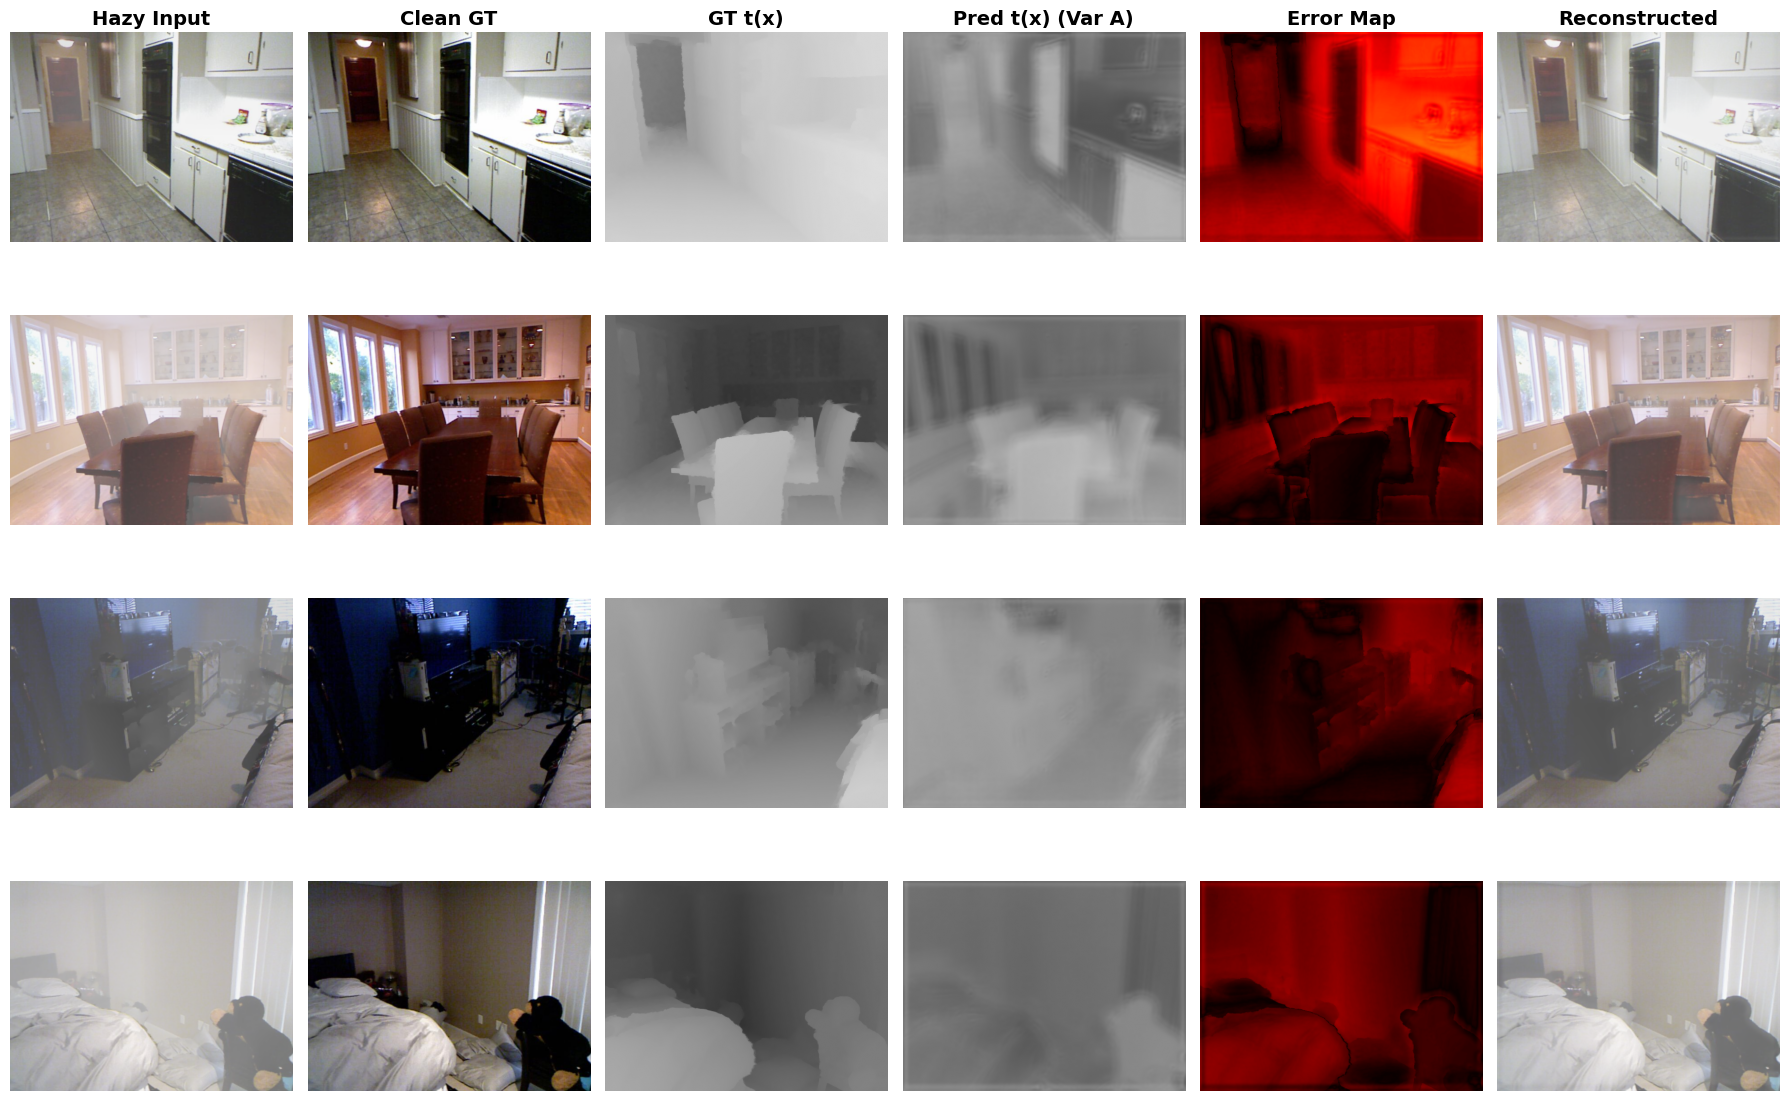

✅ Figure saved as 'Variant_A_Static_Results.pdf'


In [32]:
# 1. Grab your static test batch (e.g., the first 8 images)
static_batch = get_static_visual_batch(val_loader, batch_idx=0)

# 2. Plot Variant A
plot_variant_matplotlib_static(
    model_path="weights_experiments/model_a.pth", 
    variant='A', 
    static_batch=static_batch, 
    device=device, 
    num_samples=4 # Change to 8 if you want all of them in the plot!
)

Variant B

🎨 Generating Matplotlib visual grid for Variant B...
Initializing Stage 1 with Variant B (Anti-Aliased Downsampling)


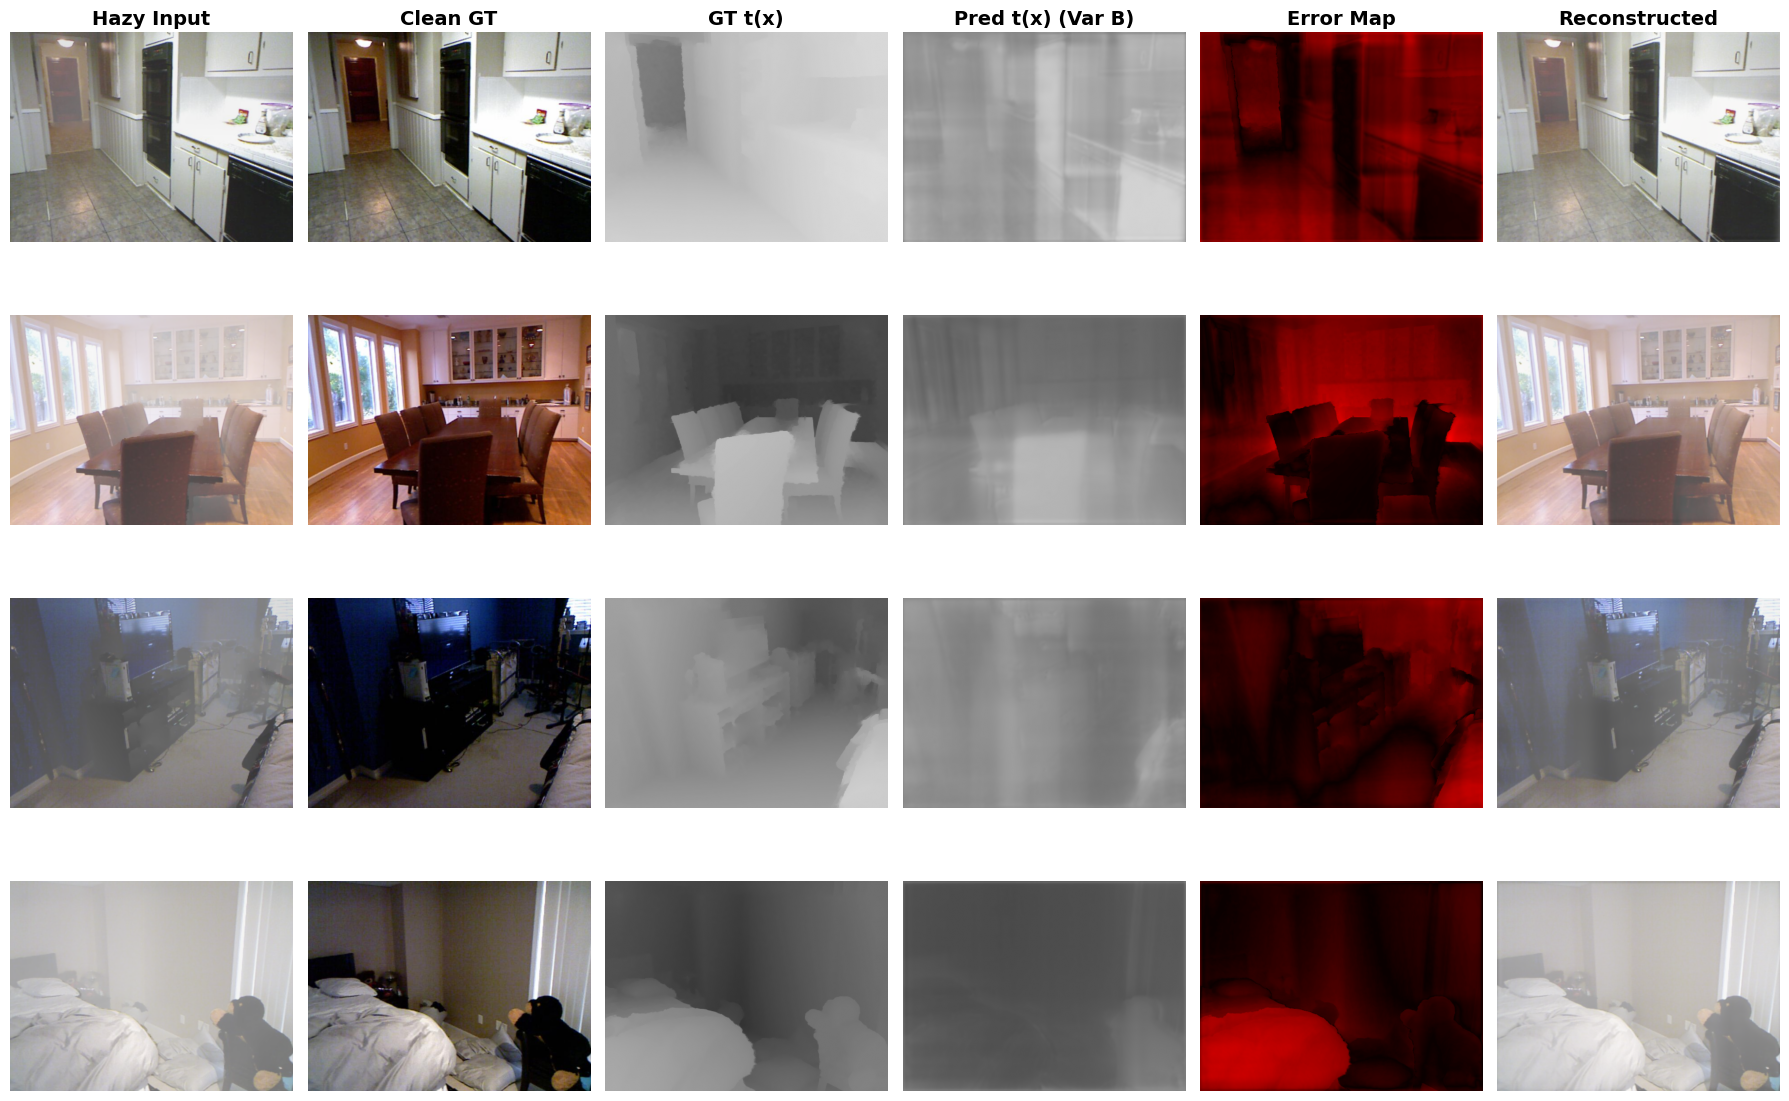

✅ Figure saved as 'Variant_B_Static_Results.pdf'


In [33]:
plot_variant_matplotlib_static(
    model_path="weights_experiments/model_b.pth", 
    variant='B', 
    static_batch=static_batch, 
    device=device, 
    num_samples=4 # Change to 8 if you want all of them in the plot!
)

DCP Model

🎨 Generating Matplotlib visual grid for the DCP Baseline...


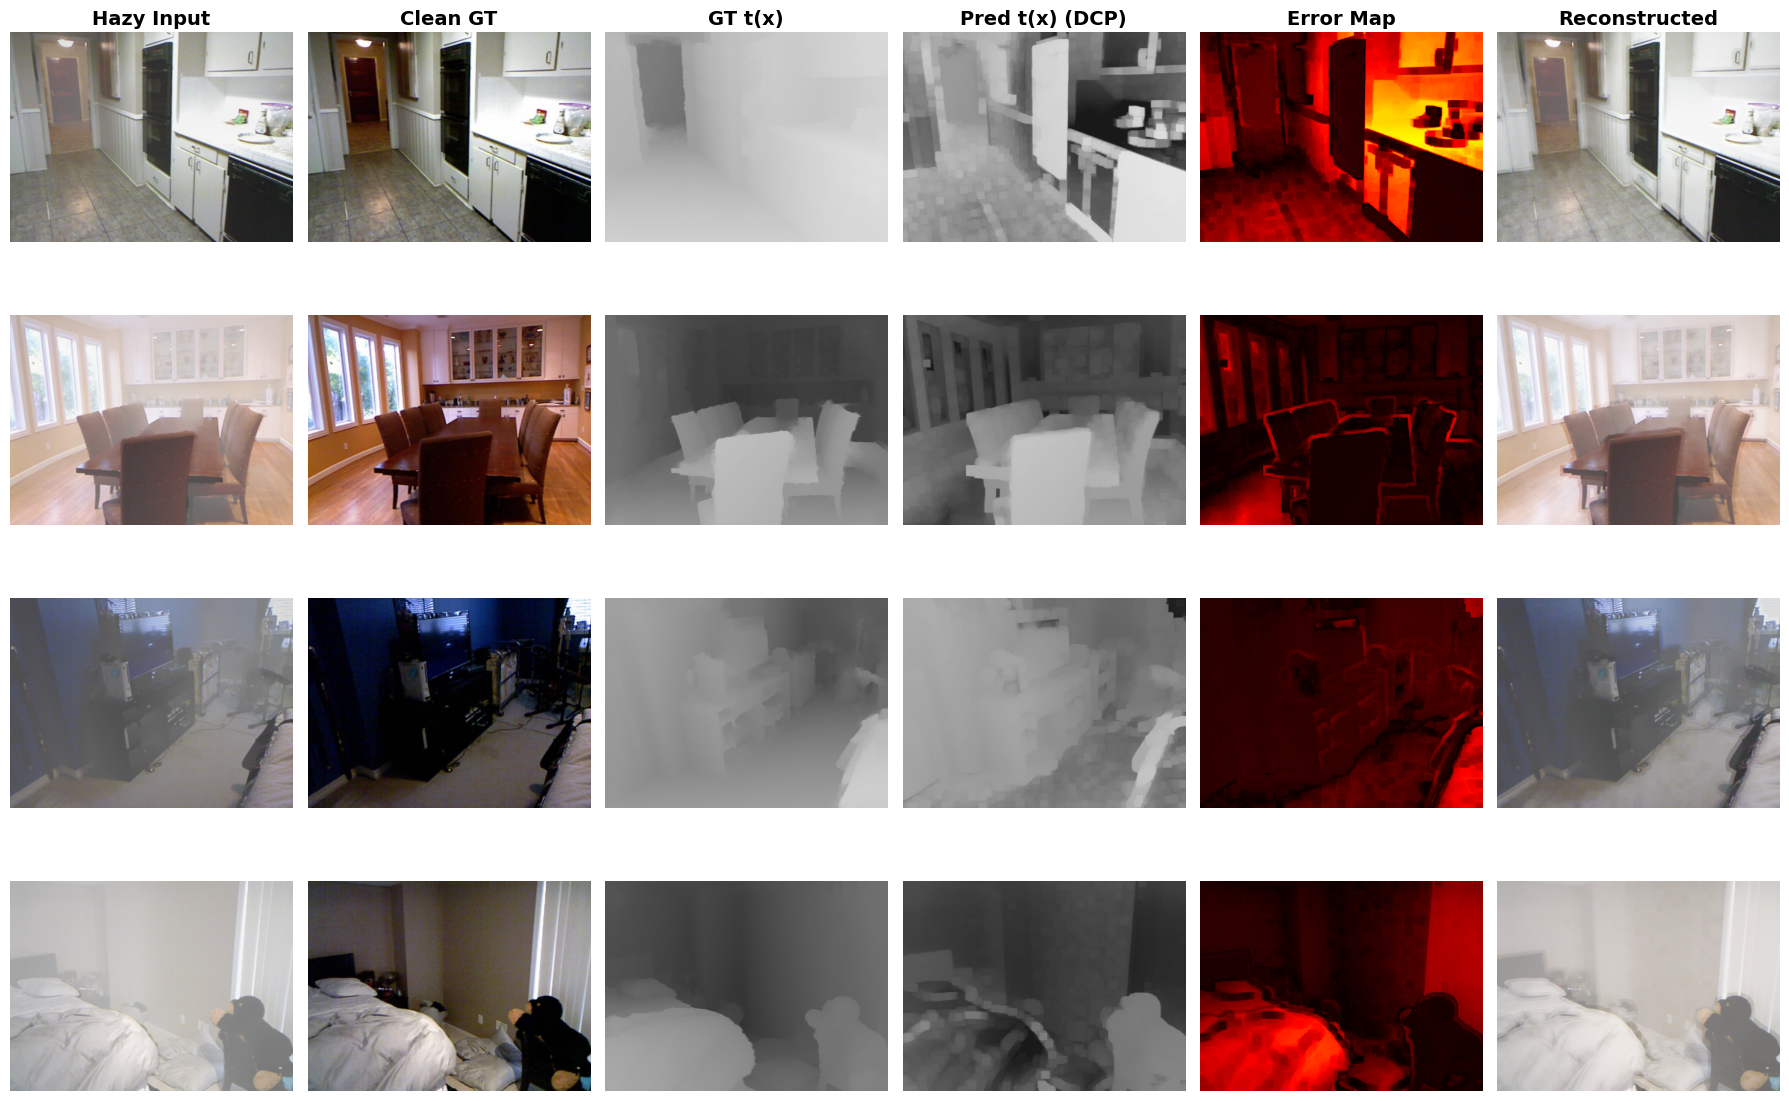

✅ Figure saved as 'DCP_Baseline_Static_Results.pdf'


In [36]:
def plot_dcp_matplotlib_static(static_batch, device, num_samples=4):
    print("🎨 Generating Matplotlib visual grid for the DCP Baseline...")
    
    # 1. Initialize the DCP model (No weights to load since it's pure math!)
    dcp_model = BatchedDCP().to(device)
    
    # 2. Unpack the static batch and move to device
    hazy_img, clean_img, gt_t_map = static_batch
    hazy_img = hazy_img.to(device)
    gt_t_map = gt_t_map.to(device)
    clean_img = clean_img.to(device)
    
    # NOTE: DCP math strictly requires inputs to be in [0, 1]. 
    # If your dataloader outputs [-1, 1], uncomment this line:
    # hazy_img = (hazy_img + 1.0) / 2.0
    
    # Ensure inputs are safely clamped between 0 and 1 just in case
    hazy_img = torch.clamp(hazy_img, 0.0, 1.0)
    
    # 3. Run inference (DCP doesn't use gradients, but we wrap it to be safe)
    with torch.no_grad():
        pred_t_map, pred_A = dcp_model(hazy_img)
        
        # Calculate Error Map
        error_map = torch.abs(pred_t_map - gt_t_map)
        
        # Calculate Reconstruction: I = J*t + A*(1-t)
        # We do this to compare how accurately DCP models the physics compared to Variant B
        I_recon = clean_img * pred_t_map + pred_A.view(-1, 3, 1, 1) * (1.0 - pred_t_map)

    # 4. Helper function to convert PyTorch tensors to Matplotlib-ready Numpy arrays
    def to_numpy(tensor):
        tensor = torch.clamp(tensor, 0.0, 1.0).detach().cpu().numpy()
        if tensor.ndim == 3:
            tensor = np.transpose(tensor, (1, 2, 0)) # (C,H,W) -> (H,W,C)
            if tensor.shape[-1] == 1:
                tensor = tensor.squeeze(-1) # (H,W,1) -> (H,W)
        return tensor

    # 5. Set up the Matplotlib Figure
    num_cols = 6
    num_rows = min(num_samples, hazy_img.size(0)) 
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 3 * num_rows))
    col_titles = ["Hazy Input", "Clean GT", "GT t(x)", "Pred t(x) (DCP)", "Error Map", "Reconstructed"]
    
    for i in range(num_rows):
        hz = to_numpy(hazy_img[i])
        cl = to_numpy(clean_img[i])
        gt_t = to_numpy(gt_t_map[i])
        pr_t = to_numpy(pred_t_map[i])
        err = to_numpy(error_map[i])
        recon = to_numpy(I_recon[i])
        
        images = [hz, cl, gt_t, pr_t, err, recon]
        
        for j, img in enumerate(images):
            ax = axes[i, j] if num_rows > 1 else axes[j]
            
            if img.ndim == 2:
                # 'hot' colormap makes the errors glow!
                cmap = 'hot' if j == 4 else 'gray' 
                ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
            else:
                ax.imshow(img)
                
            ax.axis('off') 
            
            if i == 0:
                ax.set_title(col_titles[j], fontsize=14, fontweight='bold')

    plt.tight_layout()
    save_name = "DCP_Baseline_Static_Results.pdf"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Figure saved as '{save_name}'")

# Run it!
plot_dcp_matplotlib_static(static_batch, device, num_samples=4)